# Cleaning Dataset

Combining datasets from different files. Cleaning and imputing data that are missing and not enough.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Identifiers

Sex:
    Male: 0
    Female: 1


In [16]:
clinical_ccmc = pd.read_excel("ccmc_dataset/COMPILED_DATASET.xlsx")
ccmc_only_hb = clinical_ccmc.drop('STATUS', axis=1)
ccmc_only_hb['Sex'] = ccmc_only_hb['Sex'].map({'M': 0, 'F': 1})

print(ccmc_only_hb.head())

    Age  Sex    SBP   DBP    FBS    RBS    TC   HDL   LDL    TG  HBA1C   SGPT  \
0  55.0  1.0  120.0  70.0  16.09  220.0  5.18  1.21  3.18  1.71  11.00  14.98   
1  37.0  1.0  120.0  70.0    NaN    NaN   NaN   NaN   NaN   NaN    NaN    NaN   
2  60.0  1.0  110.0  70.0  12.20    NaN  5.25  1.05  2.20  4.30   8.88  19.00   
3  51.0  1.0  100.0  70.0   4.99    NaN   NaN   NaN   NaN   NaN   4.80    NaN   
4  74.0  NaN  110.0  80.0   8.20    NaN  4.60  0.95  2.60  2.29  10.10  11.00   

   SGOT  VLDL  WEIGHT (KG)  DIABETIC  
0   NaN  0.34          NaN         1  
1   NaN   NaN          NaN         1  
2   NaN  1.95          NaN         1  
3   NaN   NaN          NaN         1  
4   NaN  1.04          NaN         1  


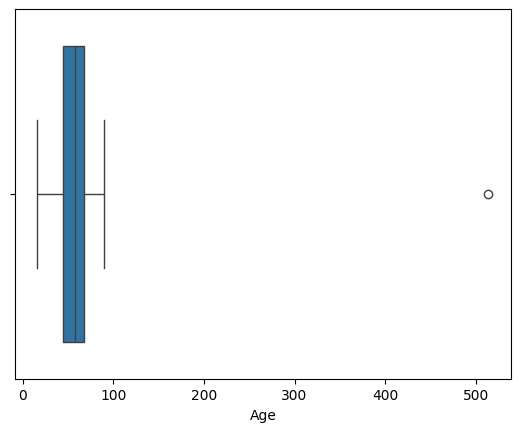

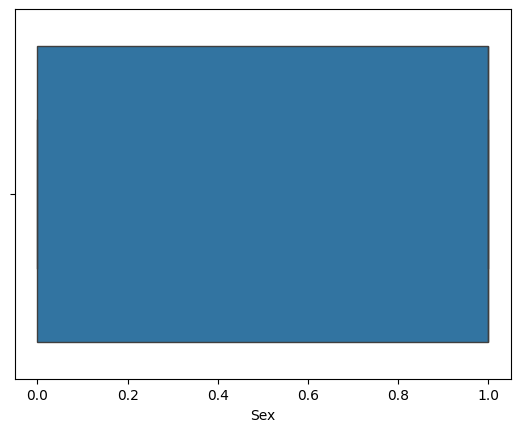

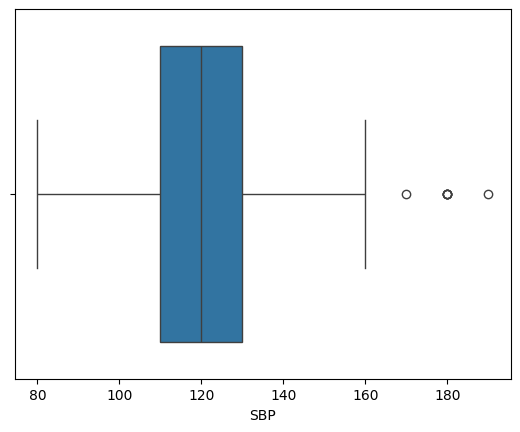

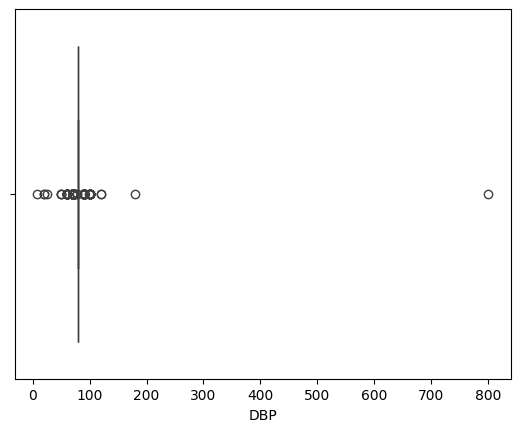

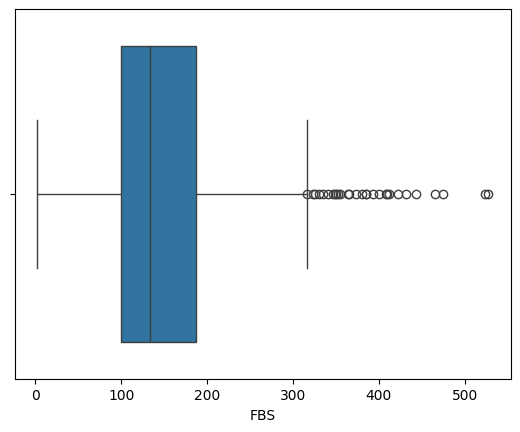

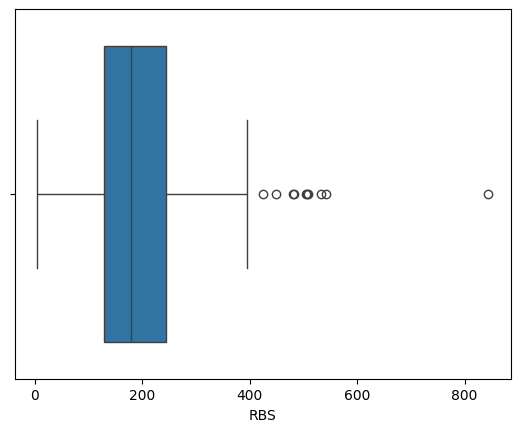

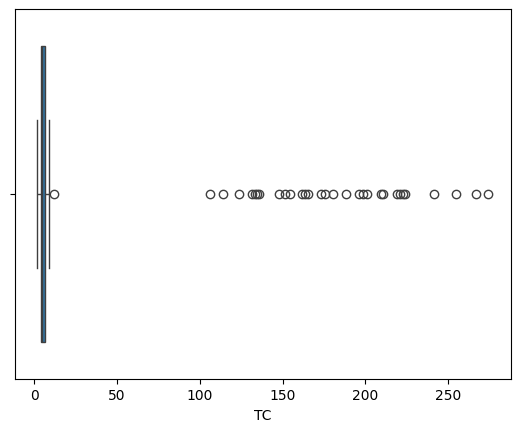

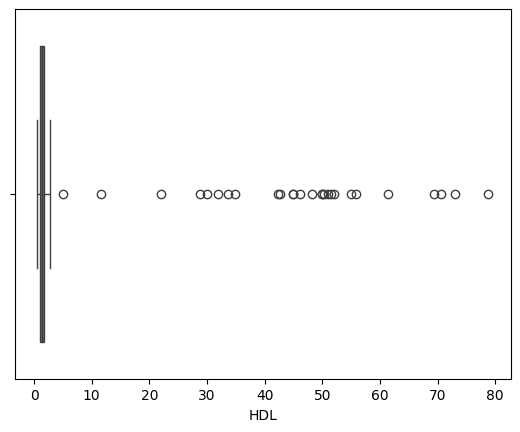

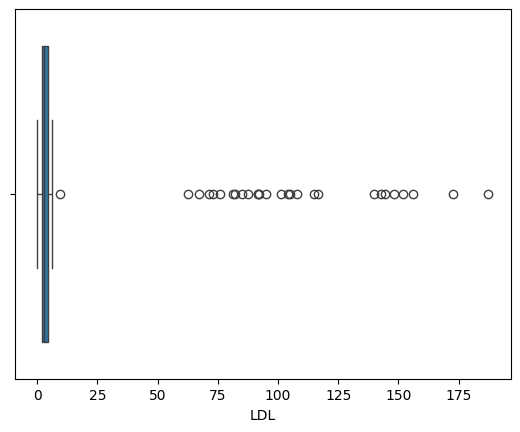

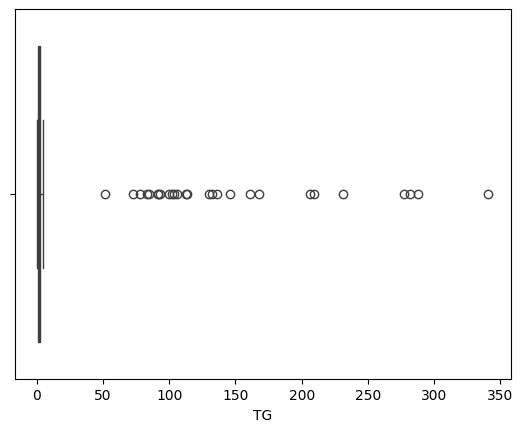

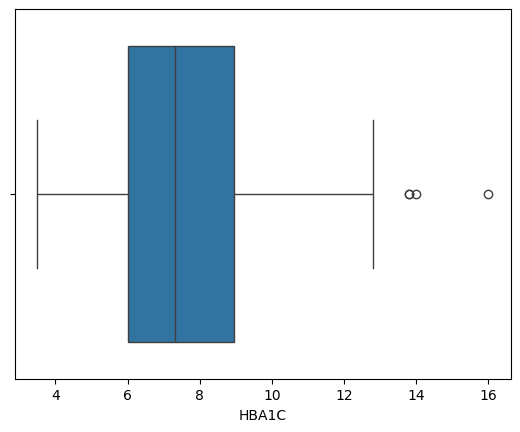

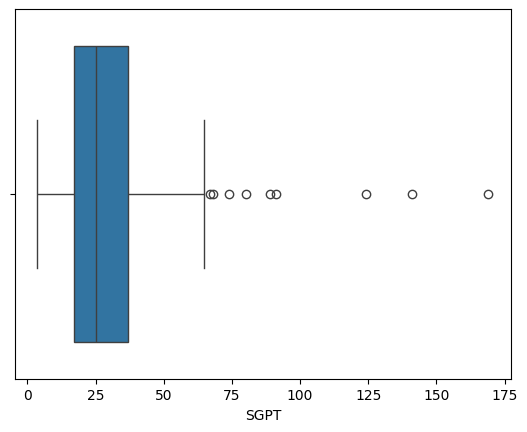

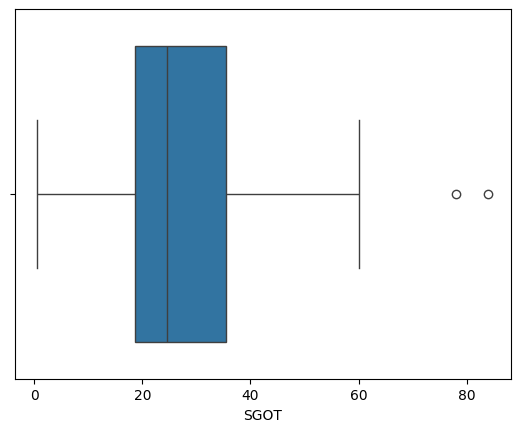

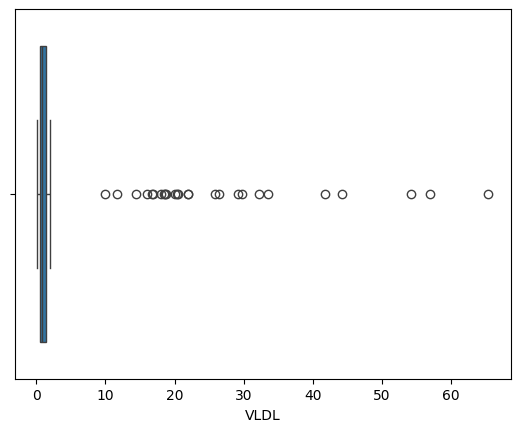

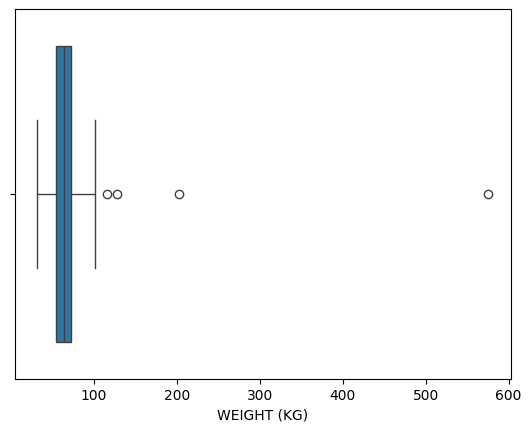

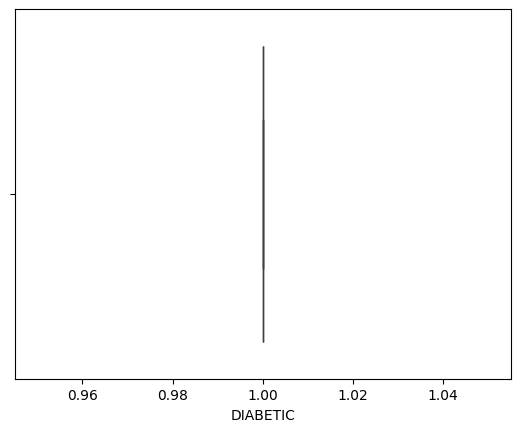

In [17]:
ccmc_only_hb_columns = ccmc_only_hb.columns
for i in ccmc_only_hb_columns:
    sns.boxplot(x=ccmc_only_hb[i])
    plt.show()

In [2]:
def load_xpt(filename):
    return pd.read_sas(filename, format="xport")

demo = load_xpt("datasets/DEMO_L.XPT")[["SEQN", "RIDAGEYR", "RIAGENDR"]]
bmx = load_xpt("datasets/BMX_L.XPT")[["SEQN", "BMXHT", "BMXWT", "BMXWAIST", "BMXHIP"]]
bpx = load_xpt("datasets/BPXO_L.XPT")[["SEQN", "BPXOSY1", "BPXODI1"]]
ghb = load_xpt("datasets/GHB_L.XPT")[["SEQN", "LBXGH"]]
glu = load_xpt("datasets/GLU_L.XPT")[["SEQN", "LBXGLU"]]
tchol = load_xpt("datasets/TCHOL_L.XPT")[["SEQN", "LBXTC"]]
hdl = load_xpt("datasets/HDL_L.XPT")[["SEQN", "LBDHDD"]]
# trigly = load_xpt("datasets/TRIGLY_J.XPT")[["SEQN", "LBXTR"]]
diabetes = load_xpt("datasets/DIQ_L.XPT")[["SEQN", "DIQ010"]]


In [3]:
dfs = [demo, bmx, bpx, ghb, glu, tchol, hdl, diabetes]
merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="SEQN", how="outer")

In [5]:
merged = merged.rename(columns={
    "RIDAGEYR": "Age",
    "RIAGENDR": "Gender",  # 1=Male, 2=Female
    "BMXHT": "Height_cm",
    "BMXWT": "Weight_kg",
    "BMXWAIST": "Waist_cm",
    "BMXHIP": "Hip_cm",
    "BPXOSY1": "Systolic_BP",
    "BPXODI1": "Diastolic_BP",
    "LBXGH": "HbA1c",
    "LBXGLU": "FBS",
    "LBXTC": "Cholesterol_Total",
    "LBDHDD": "HDL",
    "DIQ010": "Diabetes_Status"  # 1=Yes, 2=No, 3=Borderline
    #"LBXTR": "Triglycerides"
})

In [11]:
df = pd.read_csv("merged_data.csv")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

ModuleNotFoundError: No module named 'sklearn'